# AP 155 Lab Exercise
---
## Exercise 7: Root Finding

_Instructions_: 
- **Report figure:** (See Problem) Plot the convergence of the values towards the root of $f(x)$. That is, plot $x_i$ vs. $i$ for each of the four methods ($x_i$ is the output of the method on the $i$th step). Overlay the convergence curves on a single plot and check the convergence. You may have more than four curves; for instance, you could have used newton's method twice for two different guesses. Make sure to label your curves (method + initial guesses).
- **Report discussion:**
    - Explain the report figure.
    - What are the advantages and disadvantages of the root-finding methods?
- **Code**: Complete the code and ensure it is functional, error-free, readable, and efficient (where needed). Include concise Markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: De Casa, Samantha Claire E.
- _Student No._: 2023-151
- _Section_: THU-TX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Report figure

![Figure 1](Plot_of_the_function.png)

**Figure 1** shows the plot of $f(x) = -x^5 + 4x^4 - 4x^3 + x^2 e^x - 2x^2 -4xe^x + 8x + 4e^x -8$.


![Figure 2](Root_finding_methods_solution1.png)

**Figure 2** reveals the convergence curves of the bisection, newton, and secant method at $x \approx -1.19$.


![Figure 3](Root_finding_methods_solution2.png)

**Figure 3** illustrates the convergence curves of the fixed-point, bisection, newton, and secant method at $x \approx 2$.


![Figure 4](Root_finding_methods_solution3.png)

**Figure 4** shows the convergence curves of the bisection and secant method at $x \approx 4.59$.



### Report discussion
Figures 2, 3, and 4 illustrate the convergence curves of the different iterative root-finding methods, namely fixed-point, bisection, newton, and secant, for various initial bounds and guesses. As can be seen in figure 2, the curves of the bisection, newton, and secant method converged at $x \approx -1.19$, and it only took a handful of iterations to obtain these results. In figure 3, it is quite obvious that all four curves converged at $x \approx 2$. Notice, however, that the curves of the bisection and secant method converged to $x \approx -1.19$ halfway between the 1st and 50th iteration, while the curves of the fixed-point and newton method converged much later on after many many more iterations. Lastly, in figure 4, only the curves of the bisection and secant method converged at $x \approx 4.59$, and it only took a couple of iterations to arrive at these results.

Among all four root-finding methods, the fixed-point method is the easiest to implement since it doesn't require derivatives. The only downsides of this method are [1] the convergence depends strongly on the choice of $g(x)$, and [2] it has slow convergence and can take many iterations. This disadvantage is particularly evident on figure 3 where it has been shown that the fixed-point method required more than 400 iterations before converging to $x \approx 2$. On the other hand, the advantage of the bisection method over all other methods is that it is guaranteed to converge to a root if the function is continuous and changes sign on the interval. This is apparent in the results above; it is the only method whose curves converged at all three roots of $f(x)$. However, just like the fixed-point method, it has a relatively slow convergence. The newton method, on the other hand, typically converges quickly near a simple root and it often requires fewer iterations than the other methods. The only disadvantages are [1] it requires the derivative of the function, and [2] it can diverge or fail if the initial guess is poor. Finally, the advantage of the secant method is that [1] it doesn't an explicit derivative (and uses finite approximation instead) and [2] it usually converges faster than the bisection method. The only problem with it is that it can only diverge if the initial guess is poor.

---
## Section 2: Code

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

### Problem 1: Root Finding


Implement root finders *manually* to find the roots of an arbitrary function

1. fixed-point method (relaxation, needs an initial guess)
2. bisection method (bracketing, needs two bounds)
3. newton's method (known derivative, needs an initial guess)
4. secant method (approximate derivative, needs two initial guesses)

Consider the function

$$
f(x) = -x^5 + 4x^4 - 4x^3 + x^2 e^x - 2x^2 -4xe^x + 8x + 4e^x -8
$$

5. Plot the function from x=-2 to x=-5. You may want to "enlarge" the plot by rescaling/"cropping" the y-axis. You should be able to estimate where the roots are approximately
   
6. Find the roots of $f(x)$ by implementing the four methods shown.

7. Report Figure: Plot the convergence of the values towards the root of $f(x)$. That is, plot $x_i$ vs. $i$ for each of the four methods ($x_i$ is the output of the method on the $i$th step). Overlay the convergence curves on a single plot and check the convergence. You may have more than four curves; for instance, you could have used newton's method twice for two different guesses. Make sure to label your curves (method + initial guesses).

In [2]:
def f(x):
    return -x**5 + 4*(x**4) - 4*(x**3) + (x**2)*np.exp(x) - 2*(x**2) - 4*x*np.exp(x) + 8*x + 4*np.exp(x) - 8

def f_diff1(x): #first derivative of f(x)
    return -5*(x**4) + 16*(x**3) - 12*(x**2) + (x**2)*np.exp(x) + 2*x*np.exp(x) - 4*x - 4*x*np.exp(x) - 4*np.exp(x) + 8 - 4*np.exp(x)

def g(x):
    return (x**5 - 4*(x**4) + 4*(x**3) - (x**2)*np.exp(x) + 2*(x**2) + 4*x*np.exp(x) - 4*np.exp(x) + 8)/8

In [3]:
#fixed-point method
def fixedpoint(g, x0, itermax=500, tol=1e-5):
    iterations = [] #lists every ith step
    for i in range(1, itermax):
        x1 = g(x0)
        if np.abs((x1 - x0)/x1) < tol:
            iterations.append(x1)
            break
        x0 = x1
        iterations.append(x0)
    return x1, iterations,

print(fixedpoint(g, 1))

'''
This function returns a root (x~=2) when the intial guess is -1, 0, 1, or 2.
Otherwise, it returns 'nan'.
'''

(1.9921675693823322, [1.0352147714426194, 1.0693868413378314, 1.1028750965566578, 1.1359384632278562, 1.1687582243128578, 1.201451537716291, 1.234079894180498, 1.26665489598559, 1.2991430003454743, 1.3314704085182962, 1.363528910903345, 1.3951831281150622, 1.4262791909857193, 1.4566545041219694, 1.4861479008399194, 1.514609296166204, 1.5419079318863722, 1.5679384880393092, 1.5926246582165255, 1.615920162666527, 1.6378075090920405, 1.658295037927763, 1.6774128813484914, 1.695208437956865, 1.7117418570584877, 1.7270818823458938, 1.7413022613708566, 1.7544788071512594, 1.766687110929818, 1.7780008500889677, 1.7884906068742903, 1.7982231044883599, 1.8072607703142545, 1.8156615459606713, 1.8234788765702352, 1.8307618249192443, 1.8375552678758744, 1.8439001431391775, 1.8498337226843855, 1.8553898960835675, 1.8605994520717037, 1.8654903506455427, 1.8700879808696946, 1.8744154016475276, 1.8784935641836684, 1.8823415158742347, 1.8859765860313629, 1.8894145542734009, 1.892669802661783, 1.8957554

"\nThis function returns a root (x~=2) when the intial guess is -1, 0, 1, or 2.\nOtherwise, it returns 'nan'.\n"

In [4]:
#bisection method
def bisection(f, x0, x1, itermax=500, tol=1e-5):
    iterations = [] #lists every iteration
    for i in range(1, itermax):
        x2 = (x0 + x1)/2
        f0 = f(x0)
        f2 = f(x2)
    
        if f0*f2 < 0:
            x1 = x2
        else:
            x0, f0 = x2, f2
        
        x = (x0 + x1)/2
        iterations.append(x)
        if np.abs((x - x2)/x) < tol:
            break
    return x, iterations

print(bisection(f, -4, 0))
print(bisection(f, 0, 2))
print(bisection(f, 2, 6))

'''
This function returns all 3 roots (x~=-1.19, x~=2, x~=4.59).
'''

(-1.1926803588867188, [-1.0, -1.5, -1.25, -1.125, -1.1875, -1.21875, -1.203125, -1.1953125, -1.19140625, -1.193359375, -1.1923828125, -1.19287109375, -1.192626953125, -1.1927490234375, -1.19268798828125, -1.192657470703125, -1.1926727294921875, -1.1926803588867188])
(1.9999847412109375, [1.5, 1.75, 1.875, 1.9375, 1.96875, 1.984375, 1.9921875, 1.99609375, 1.998046875, 1.9990234375, 1.99951171875, 1.999755859375, 1.9998779296875, 1.99993896484375, 1.999969482421875, 1.9999847412109375])
(4.595855712890625, [5.0, 4.5, 4.75, 4.625, 4.5625, 4.59375, 4.609375, 4.6015625, 4.59765625, 4.595703125, 4.5966796875, 4.59619140625, 4.595947265625, 4.5958251953125, 4.59588623046875, 4.595855712890625])


'\nThis function returns all 3 roots (x~=-1.19, x~=2, x~=4.59).\n'

In [5]:
#newton's method
def newton(f, fdiff, x0, itermax=500, tol=1e-5):
    iterations = [] #lists every iteration
    for i in range(1, itermax):
        x1 = x0 - (f(x0)/fdiff(x0))
        if np.abs((x1 - x0)/x1) < tol:
            iterations.append(x1)
            break
        
        x0 = x1
        iterations.append(x0)
    return x1, iterations

print(newton(f, f_diff1, -1))
print(newton(f, f_diff1, 1))

'''
This function returns 2 out of 3 roots (x~=-1.19 and x~=2).
'''

(-1.1926858473140522, [-1.2490908572664974, -1.1995496439344184, -1.193133310996511, -1.192711377348682, -1.192687217195272, -1.1926858473140522])
(2.0421382600279507, [0.9868751802715738, 0.9733652079354468, 0.959421997340884, 0.9449887810557376, 0.929998050578516, 0.9143688453032309, 0.8980031277291427, 0.8807808522846421, 0.8625531248415035, 0.8431325011549733, 0.8222788737701588, 0.7996783285170258, 0.774910356675966, 0.7473948798437451, 0.71630229870173, 0.6803910791803273, 0.637690694766706, 0.5848156807341234, 0.5152547964343004, 0.4140954782929235, 0.23468794534688506, -0.3414667384389479, 2.8534133380935525, 2.8169235651283695, 2.783211981667753, 2.7520139203690768, 2.7230903245301485, 2.6962261869982487, 2.6712286721178864, 2.647925122829897, 2.6261610806311064, 2.6057983949041907, 2.5867134636841125, 2.568795625324587, 2.5519457061356414, 2.536074720265412, 2.521102713045745, 2.5069577364243725, 2.4935749440828583, 2.4808957937911256, 2.4688673450771206, 2.457441641132037, 2

'\nThis function returns 2 out of 3 roots (x~=-1.19 and x~=2).\n'

In [6]:
#secant method
def secant(f, x0, x1, itermax=500, tol=1e-5):
    iterations = [] #lists every iteration
    for i in range(1, itermax):
        f0 = f(x0)
        f1 = f(x1)
        x2 = x1 - f1*((x1 - x0)/(f1 - f0))
        
        if np.abs((x2 - x1)/ x2) < tol:
            iterations.append(x2)
            break
        
        x0, x1 = x1, x2
        f0 = f1
        iterations.append(x1)
    return x2, iterations

print(secant(f, -4, -1))
print(secant(f, 0, 3))
print(secant(f, -2, 5))

'''
This function returns all 3 roots (x~=-1.19, x~=2, x~=4.59).
'''

(-1.192685764780162, [-1.007624932169697, -1.2811894310228988, -1.1647962392874238, -1.1890420427427169, -1.1928500758499672, -1.1926848234702783, -1.192685764780162])
(2.000023604343922, [-2.441772338593614, 2.8122668487559235, 2.7088269815087496, 2.480296775936497, 2.3543087541083985, 2.245790080394903, 2.1694003740988093, 2.1133265681499918, 2.0744459391278265, 2.0480009386003384, 2.03054549867575, 2.019243572921506, 2.012042031717256, 2.0075013538124176, 2.004659215230336, 2.0028885164460126, 2.0017886604172777, 2.0011067817674673, 2.0006845383443896, 2.0004232630407235, 2.000261665578305, 2.000161746739485, 2.000099975882609, 2.0000617926771724, 2.00003819151863, 2.000023604343922])
(4.5958635651300535, [-9.267427389510335, 5.027331633142797, 5.057894839821199, 4.782326818147914, 4.687373579755359, 4.619450813420475, 4.599287053415239, 4.596002822019067, 4.5958644065102, 4.5958635651300535])


'\nThis function returns all 3 roots (x~=-1.19, x~=2, x~=4.59).\n'

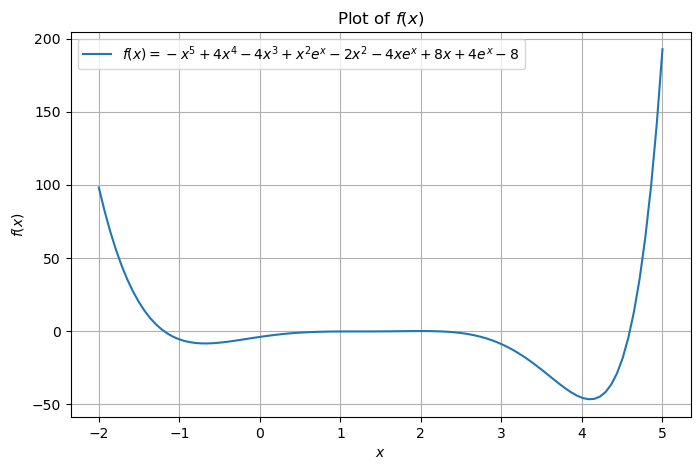

In [7]:
x = np.linspace(-2, 5, 100)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(x, f(x), label=r"$f(x) = -x^5 + 4x^4 - 4x^3 + x^2e^x - 2x^2 - 4xe^x + 8x + 4e^x - 8$")
ax.set_title(r"Plot of $f(x)$")
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$f(x)$")
ax.legend()
ax.grid(True)

fig.show()
fig.savefig("Plot_of_the_function.png")

In [8]:
'''results of the fixed-point method'''
fixed_point_method = fixedpoint(g, 1)[1] #list of iterations when the initial guess is 1
N_fpm = np.arange(1, len(fixed_point_method) + 1)


'''results of the bisection method'''
bisection_method1 = bisection(f, -4, 0)[1] #list of iterations when the bounds are -4 and 0
N_bm1 = np.arange(1, len(bisection_method1) + 1)

bisection_method2 = bisection(f, 0, 2)[1] #list of iterations when the bounds are 0 and 2
N_bm2 = np.arange(1, len(bisection_method2) + 1)

bisection_method3 = bisection(f, 2, 6)[1] #list of iterations when the bounds are 2 and 6
N_bm3 = np.arange(1, len(bisection_method3) + 1)


'''results of the newton method'''
newton_method1 = newton(f, f_diff1, -1)[1] #list of iterations when the initial guess is -1
N_nm1 = np.arange(1, len(newton_method1) + 1)

newton_method2 = newton(f, f_diff1, 1)[1] #list of iterations when the initial guess is 1
N_nm2 = np.arange(1, len(newton_method2) + 1)


'''resutls of the secant method'''
secant_method1 = secant(f, -4, -1)[1] #list of iterations when the two initial guesses are -4 and -1
N_sm1 = np.arange(1, len(secant_method1) + 1)

secant_method2 = secant(f, 0, 3)[1]
N_sm2 = np.arange(1, len(secant_method2) + 1) #list of iterations when the two initial guesses are 0 and 3

secant_method3 = secant(f, -2, 5)[1] #list of iterations when the two initial guesses are -2 and -5
N_sm3 = np.arange(1, len(secant_method3) + 1)

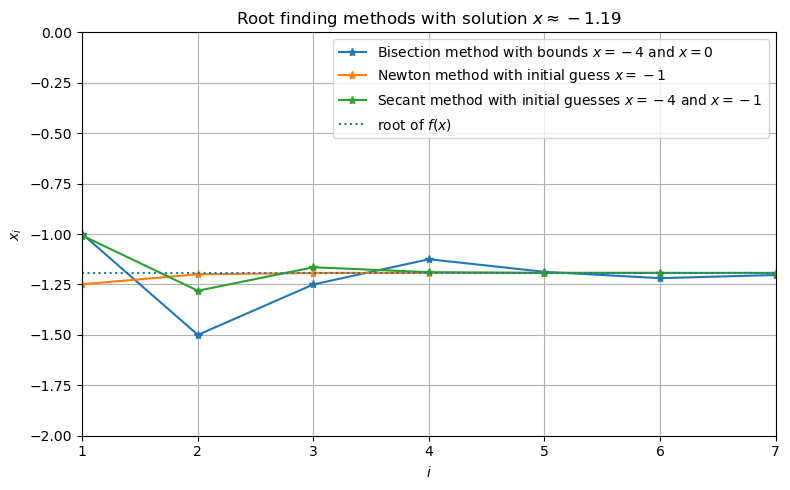

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(N_bm1, bisection_method1, marker="*", label=r"Bisection method with bounds $x=-4$ and $x=0$")
ax.plot(N_nm1, newton_method1, marker="*", label=r"Newton method with initial guess $x=-1$")
ax.plot(N_sm1, secant_method1, marker="*", label=r"Secant method with initial guesses $x=-4$ and $x=-1$")

ax.axhline(newton_method1[5], linestyle=":", label=r"root of $f(x)$")

ax.set_title(r"Root finding methods with solution $x \approx -1.19$")
ax.set_xlabel(r"$i$")
ax.set_ylabel(r"$x_i$")
ax.set_ylim(-2, 0)
ax.set_xlim(1, 7)
ax.legend()
ax.grid(True)

fig.tight_layout()
fig.show()
fig.savefig("Root_finding_methods_solution1.png")

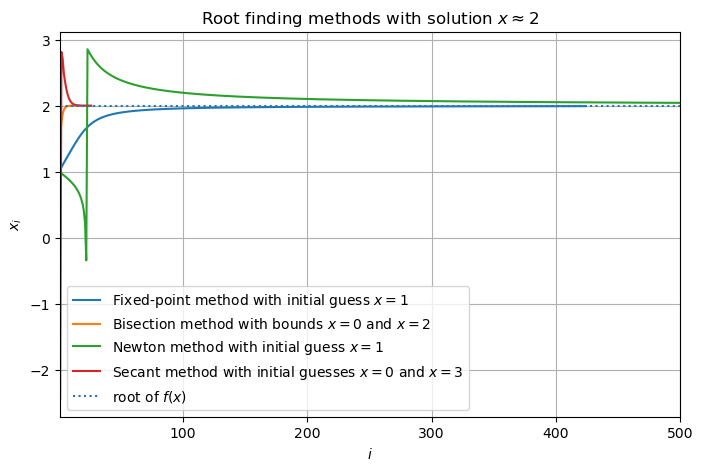

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(N_fpm, fixed_point_method, label=r"Fixed-point method with initial guess $x=1$")
ax.plot(N_bm2, bisection_method2, label=r"Bisection method with bounds $x=0$ and $x=2$")
ax.plot(N_nm2, newton_method2, label=r"Newton method with initial guess $x=1$")
ax.plot(N_sm2, secant_method2, label=r"Secant method with initial guesses $x=0$ and $x=3$")

ax.axhline(2, linestyle=":", label=r"root of $f(x)$")

ax.set_title(r"Root finding methods with solution $x \approx 2$")
ax.set_xlabel(r"$i$")
ax.set_ylabel(r"$x_i$")
ax.set_xlim(1, 500)
ax.legend()
ax.grid(True)

fig.show()
fig.savefig("Root_finding_methods_solution2.png")

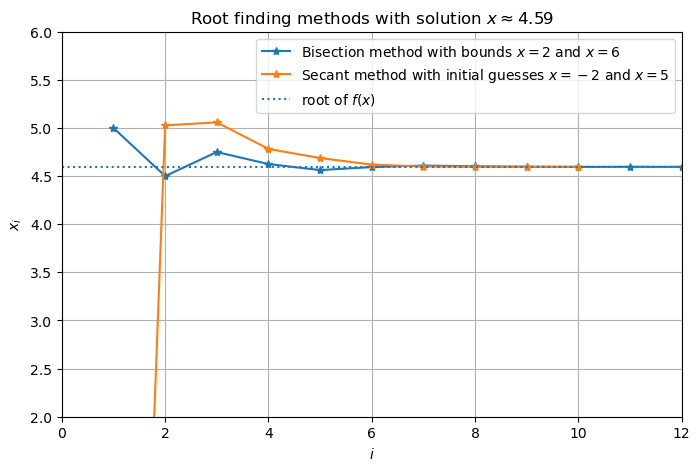

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(N_bm3, bisection_method3, marker="*", label=r"Bisection method with bounds $x=2$ and $x=6$")
ax.plot(N_sm3, secant_method3, marker="*", label=r"Secant method with initial guesses $x=-2$ and $x=5$")

ax.axhline(bisection_method3[10], linestyle=":", label=r"root of $f(x)$")

ax.set_title(r"Root finding methods with solution $x \approx 4.59$")
ax.set_xlabel(r"$i$")
ax.set_ylabel(r"$x_i$")
ax.set_ylim(2, 6)
ax.set_xlim(0, 12)
ax.legend()
ax.grid(True)

fig.show()
fig.savefig("Root_finding_methods_solution3.png")

#### Problem 1 code summary

The purpose of this algorithm is to solve for the roots of $f(x)$ using the fixed-point iteration, bisection, newton, and secant method. Notice that inside every function I created (`fixedpoint()`, `bisection()`, `newton()`, and `secant()`), I defined a local variable/list named `iterations` so that I can compile the output $x_i$ on every $i$th step and plot the results.

---